In [33]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('books.csv')
print(df.head())

print(df.info)

                                   Title   Price Availability Rating
0                   A Light in the Attic  £51.77     In stock  Three
1                     Tipping the Velvet  £53.74     In stock    One
2                             Soumission  £50.10     In stock    One
3                          Sharp Objects  £47.82     In stock   Four
4  Sapiens: A Brief History of Humankind  £54.23     In stock   Five
<bound method DataFrame.info of                                                  Title   Price Availability  \
0                                 A Light in the Attic  £51.77     In stock   
1                                   Tipping the Velvet  £53.74     In stock   
2                                           Soumission  £50.10     In stock   
3                                        Sharp Objects  £47.82     In stock   
4                Sapiens: A Brief History of Humankind  £54.23     In stock   
..                                                 ...     ...          ...   
4

In [34]:

# نتأكد أن أسماء الكتب ليس بها مسافات مخفية في البداية أو النهاية
df['Title'] = df['Title'].str.strip()
#ازالة الرمز وتحويله ل float
df['Price'] = df['Price'].replace(r'[^\d.]', '', regex=True).astype(float)
print(" data type of price:", df['Price'].dtype)
print("max price: ", df['Price'].max())



 data type of price: float64
max price:  59.9


In [35]:
#ننشئ "قاموس" للتحويل من كلمات لأرقام
df['Rating'] = df['Rating'].str.strip().str.lower()
rating_dict = {
    'one': 1,
    'two': 2,
    'three': 3,
    'four': 4,
    'five': 5
}
df['Rating'] = df['Rating'].map(rating_dict)
print(df.head())

                                   Title  Price Availability  Rating
0                   A Light in the Attic  51.77     In stock       3
1                     Tipping the Velvet  53.74     In stock       1
2                             Soumission  50.10     In stock       1
3                          Sharp Objects  47.82     In stock       4
4  Sapiens: A Brief History of Humankind  54.23     In stock       5


In [38]:
print(f"mean price books: {df['Price'].mean():.2f} ")
print(f"expensive price book: {df['Price'].max()} ")
print(f"chip price book {df['Price'].min()} ")

mean price books: 35.04 
expensive price book: 59.9 
chip price book 10.16 


In [40]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# سننشئ عموداً جديداً باسم Price_Normalized
df['Price_Normalized'] = scaler.fit_transform(df[['Price']])
print(df['Price_Normalized'],df['Price'])

0      0.836550
1      0.876156
2      0.802975
3      0.757137
4      0.886007
         ...   
495    0.727181
496    0.546240
497    0.309409
498    0.493768
499    0.518697
Name: Price_Normalized, Length: 500, dtype: float64 0      51.77
1      53.74
2      50.10
3      47.82
4      54.23
       ...  
495    46.33
496    37.33
497    25.55
498    34.72
499    35.96
Name: Price, Length: 500, dtype: float64


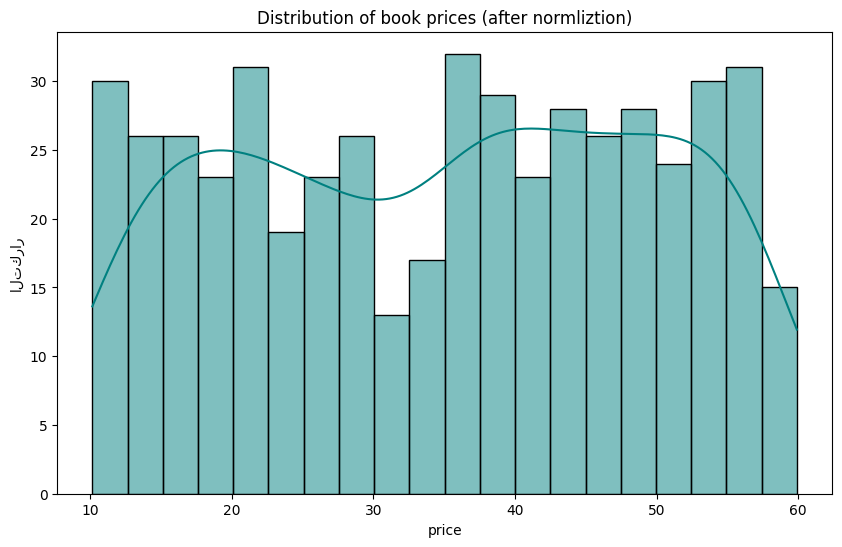

In [ ]:
plt.figure(figsize=(10, 6))


sns.histplot(df['Price'], bins=20, kde=True, color='teal')

plt.title('')
plt.xlabel('price')
plt.ylabel('التكرار')
plt.show()